In [43]:
import pandas as pd
import json

pd.set_option('display.max_columns', 500)

# MARKET = "base_cbbtc_usdc_full"
# MARKET = "eth_cbbtc_usdc"
# MARKET = "eth_wbtc_usdc"
# MARKET = "eth_wsteth_usdc"

CRYPTO_MARKETS = [
    'eth_wbtc_usdc', 'base_wbtc_usdt', 'eth_cbbtc_usdc',
    'eth_wbtc_usdt', "eth_wsteth_usdt", 'eth_weth_usdt', 'eth_cbbtc_usdt',
]

MARKET = "base_wbtc_usdt"

df = pd.read_csv(
    f"/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_enriched/{MARKET}.csv"
)
with open("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/common/markets_meta.json", 'r') as f:
    markets_meta = json.load(f)
with open("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/common/assets_meta.json", 'r') as f:
    assets_meta = json.load(f)
market_addr = df["market_address"].unique()[0]
market_meta = markets_meta[market_addr]
asset_meta = assets_meta[market_meta["collateral_asset_address"]]

df.columns

Index(['hash', 'type', 'timestamp', 'user_address', 'assets', 'assets_usd',
       'market', 'datetime', 'market_address', 'total_supply_before',
       'total_borrow_before', 'total_supply_after', 'total_borrow_after',
       'utilization_before', 'utilization_after', 'tx_actions',
       'borrow_rate_before', 'supply_rate_before', 'borrow_rate_after',
       'supply_rate_after', 'collateral_price', 'loan_asset_price',
       'collateral_before', 'collateral_value_before', 'debt_before',
       'ltv_before', 'collateral_after', 'collateral_value_after',
       'debt_after', 'ltv_after', 'health_factor_before',
       'health_factor_after', 'event_type', 'vault_flg', 'volatility_1h',
       'drawdown_1h', 'trend_1h', 'volatility_6h', 'drawdown_6h', 'trend_6h',
       'volatility_24h', 'drawdown_24h', 'trend_24h'],
      dtype='object')

In [44]:
markets_meta

{'0xe7e9694b754c4d4f7e21faf7223f6fa71abaeb10296a4c43a54a7977149687d2': {'address': '0xe7e9694b754c4d4f7e21faf7223f6fa71abaeb10296a4c43a54a7977149687d2',
  'lltv': '860000000000000000',
  'oracle_address': '0x95DB30fAb9A3754e42423000DF27732CB2396992',
  'creation_datetime': 1706722763,
  'network': 'eth',
  'loan_asset_address': '0xdAC17F958D2ee523a2206206994597C13D831ec7',
  'loan_asset_symbol': 'USDT',
  'loan_asset_decimals': 6,
  'collateral_asset_address': '0x7f39C581F595B53c5cb19bD0b3f8dA6c935E2Ca0',
  'collateral_asset_symbol': 'wstETH',
  'collateral_asset_decimals': 18,
  'rate_at_target': {'1772959127': 866053518,
   '1772956800': 865557466,
   '1772953200': 864982974,
   '1772949600': 864783375,
   '1772946000': 864714137,
   '1772942400': 864645300,
   '1772938800': 864603675,
   '1772935200': 864418377,
   '1772931600': 864380862,
   '1772928000': 864342980,
   '1772924400': 864301706,
   '1772920800': 864272297,
   '1772917200': 864246686,
   '1772913600': 864174695,
   '1

In [45]:
df.head(1).to_dict()
from tqdm.auto import tqdm
import numpy as np

def create_market_hourly_dataset(df, asset_meta):
    # Generate hourly timestamps
    min_time = df['timestamp'].min()
    max_time = df['timestamp'].max()
    
    start_hour = (min_time // 3600) * 3600
    end_hour = ((max_time // 3600) + 1) * 3600
    
    hourly_ts = np.arange(start_hour, end_hour + 3600, 3600)
    
    # Sort events
    df_sorted = df.sort_values('timestamp')
    events_ts = df_sorted['timestamp'].values
    
    # Find last event index for each hour using searchsorted
    idx = np.searchsorted(events_ts, hourly_ts, side='right') - 1
    
    # Extract values
    result_data = []
    for i, hour_ts in tqdm(enumerate(hourly_ts)):
        if idx[i] >= 0:
            last_row = df_sorted.iloc[idx[i]]
            row_data = {
                'timestamp': hour_ts,
                'datetime': pd.to_datetime(hour_ts, unit='s'),
                'total_supply': last_row['total_supply_after'],
                'total_borrow': last_row['total_borrow_after'],
                'utilization': last_row['utilization_after'],
                'borrow_rate': last_row['borrow_rate_after'],
                'supply_rate': last_row['supply_rate_after'],
                'volatility_1h': last_row.get('volatility_1h', 0),
                'drawdown_1h': last_row.get('drawdown_1h', 0),
                'volatility_6h': last_row.get('volatility_6h', 0),
                'drawdown_6h': last_row.get('drawdown_6h', 0),
                'collateral_price': last_row.get('collateral_price', 0),
                'loan_asset_price': last_row.get('loan_asset_price', 0),
                'avg_health_factor': last_row.get('health_factor_after', 0)
            }
        else:
            row_data = {
                'timestamp': hour_ts,
                'datetime': pd.to_datetime(hour_ts, unit='s'),
                'total_supply': 0,
                'total_borrow': 0,
                'utilization': 0,
                'borrow_rate': 0,
                'supply_rate': 0,
                'volatility_1h': 0,
                'drawdown_1h': 0,
                'volatility_6h': 0,
                'drawdown_6h': 0,
                'collateral_price': 0,
                'loan_asset_price': 0,
                'avg_health_factor': 0
            }
        result_data.append(row_data)
    
    result_df = pd.DataFrame(result_data)
    
    # Forward fill
    result_df = result_df.ffill().fillna(0)
    
    # Add rolling means (after forward fill to avoid NaN)
    result_df['borrow_rate_rolling'] = result_df['borrow_rate'].rolling(6, min_periods=1).mean()
    result_df['supply_rate_rolling'] = result_df['supply_rate'].rolling(6, min_periods=1).mean()
    
    # Add asset price
    if 'historical_price' in asset_meta and asset_meta['historical_price']:
        price_df = pd.DataFrame(asset_meta['historical_price'], columns=['timestamp', 'price'])
        price_df = price_df.dropna()
        if not price_df.empty:
            result_df = result_df.merge(price_df, on='timestamp', how='left')
            result_df['asset_price'] = result_df['price'].ffill().fillna(0)
            result_df = result_df.drop(columns=['price'])
    
    return result_df
hourly_df = create_market_hourly_dataset(
    df,
    asset_meta,
)

0it [00:00, ?it/s]

<Axes: >

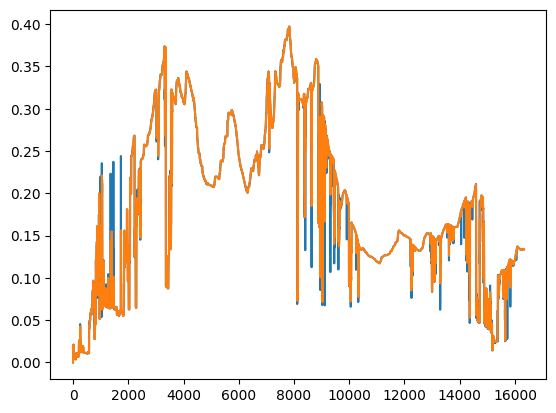

In [46]:
hourly_df["borrow_rate"].plot()
hourly_df["borrow_rate_rolling"].plot()

# hourly_df["total_supply"].plot()

In [47]:
hourly_df["borrow_rate"]
# hourly_df.head(2)

df[df["datetime"]>"2025-12-01"]["borrow_rate_after"]

25736    0.119136
25737    0.119136
25738    0.119136
25739    0.119136
25740    0.119136
           ...   
27903    0.133858
27904    0.133832
27905    0.133832
27906    0.133832
27907    0.133832
Name: borrow_rate_after, Length: 2172, dtype: float64

In [48]:
hourly_df.to_csv(f"/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_hourly_data/{MARKET}.csv",index=False)


In [49]:
hourly_df["datetime"].max()

Timestamp('2025-12-16 15:00:00')